# Robustness / falsifiers — Hold checklist

**NOTES:** [`NOTES.md`](NOTES.md) · **EXP:** [`EXP_REPORT.md`](EXP_REPORT.md)

Desk falsifiers without SPX GIV: chronological split, IV placebo (shuffle IV within day if hourly arrives), venue-drop (2-venue vs spot_l2), no-synth. **Never** soft-Promote TOB-cross α. Warehouse OI futures-only remains quarantined.


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / "research" / "books" / "squeeze_metrics"
OUT = BOOK / "out"
SCRIPTS = BOOK / "scripts"
ROOT = BOOK.parents[2]
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(ROOT))
from _nb_common import (
    load_json, gex_day_table, safe_corr, partial_corr_vs_rv, lead_lag_day, SIGNAL_BOARD,
)
from certified_panel import load_certified, primary_days, spot_l2_days, gex_panel_days, DDOI_LABEL, GEX_PROXY_LABEL
from research.lib import squeeze  # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def show_pngs(fig_dir: Path, pattern="*.png"):
    if not fig_dir.is_dir():
        print("no figs dir", fig_dir)
        return
    for p in sorted(fig_dir.glob(pattern)):
        display(Markdown(f"**{p.name}** — `{p.relative_to(BOOK)}`"))
        display(Image(filename=str(p)))

def print_board(rows=None):
    rows = rows or SIGNAL_BOARD
    print(f"{'id':34s} {'gate':6s} note")
    print("-" * 88)
    for i, g, n in rows:
        print(f"{i:34s} {g:6s} {n}")

CERT = load_certified()
PRIMARY = primary_days(CERT)
SPOT = spot_l2_days(CERT)
GEX_DAYS = gex_panel_days(CERT)
print("BOOK", BOOK)
print("certified primary n=", len(PRIMARY), PRIMARY)
print("panel_gex_options n=", len(GEX_DAYS), GEX_DAYS)
print("spot_l2 subpanel n=", len(SPOT), SPOT)
print("DDOI label", DDOI_LABEL, "| GEX proxy", GEX_PROXY_LABEL)
print("trade_synth QUARANTINED — never primary; warehouse OI futures-only unused")


BOOK /home/dev/srv/ares-microstructure/research/books/squeeze_metrics
certified primary n= 9 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
panel_gex_options n= 11 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-19', '2026-09-25', '2026-09-26', '2026-09-27', '2026-09-29', '2026-10-01']
spot_l2 subpanel n= 5 ['2026-09-25', '2026-09-26', '2026-09-27', '2026-09-29', '2026-10-01']
DDOI label PROXY_trade_flow_DDOI | GEX proxy BS_GEX_trade_flow_DDOI
trade_synth QUARANTINED — never primary; warehouse OI futures-only unused


n_ok 9 spot_l2 days in panel 4
blockers {'option_oi': 'Deribit warehouse open_interest is FUTURES-ONLY. Option DDOI uses PROXY_trade_flow_DDOI (or live API OI snapshot).', 'clickhouse_mcp': 'BANNED — not used'}
pass2b decision Hold promote False count 0
chrono GEX↔RV stable True GEX↔range False
day-block corr(GEX,HL RV) -0.2162754128722743 CI [-0.7386447742588608, 0.5912940092387926]
kill ['alpha.tob_cross_arb', 'data.trade_synth']


**fig_chrono_split.png** — `out/pass2/figs/fig_chrono_split.png`

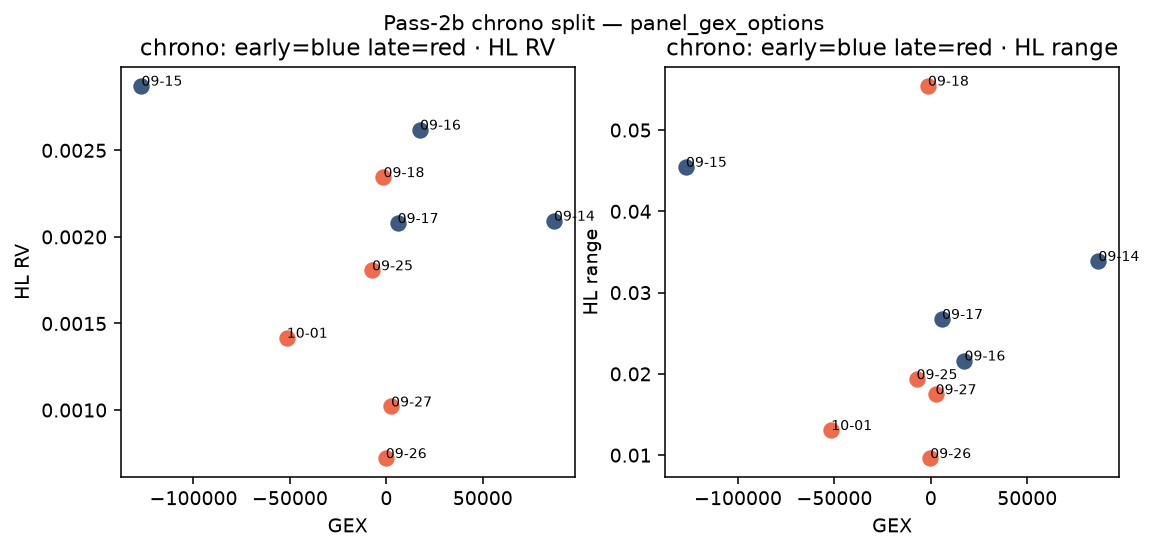

**fig_dayblock_ci.png** — `out/pass2/figs/fig_dayblock_ci.png`

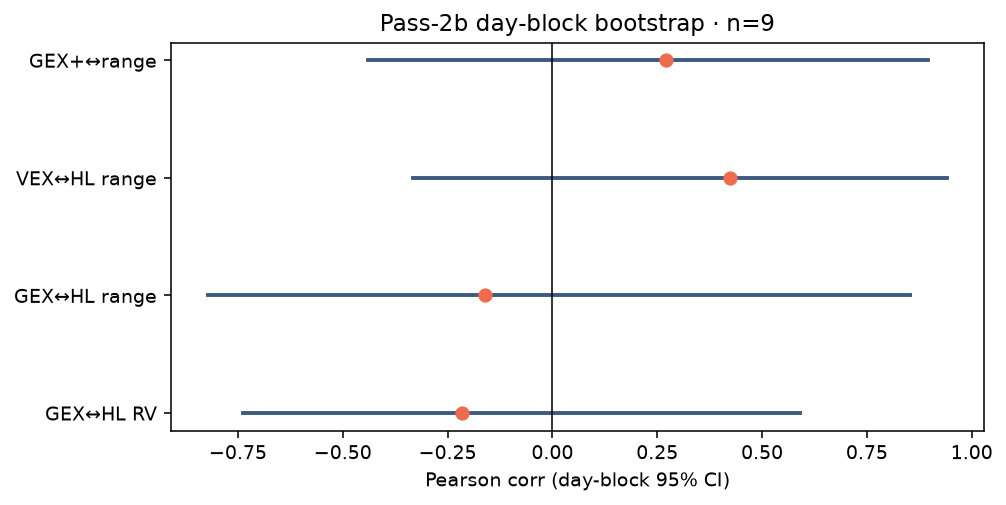

**fig_loo_corr.png** — `out/pass2/figs/fig_loo_corr.png`

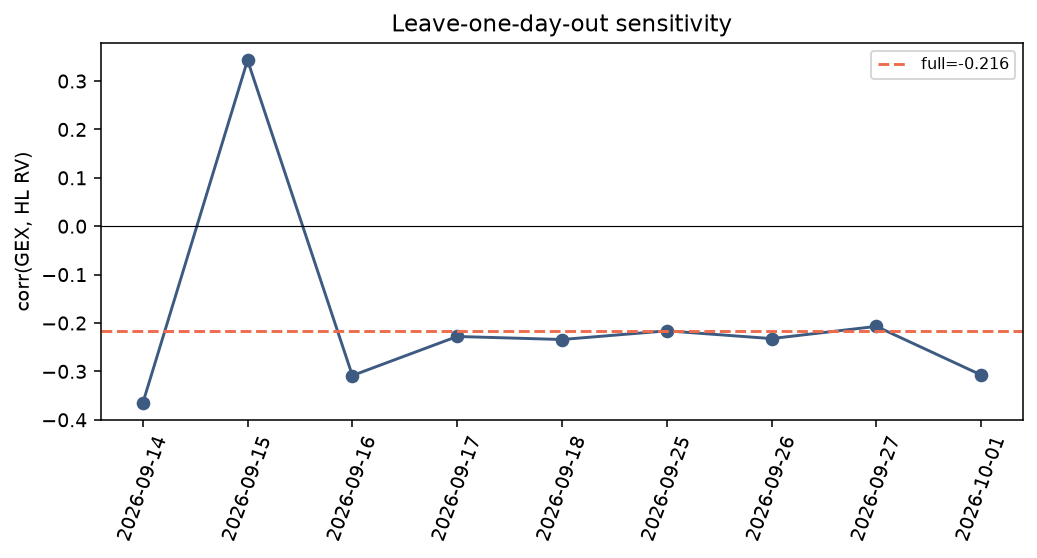

**fig_venue_drop.png** — `out/pass2/figs/fig_venue_drop.png`

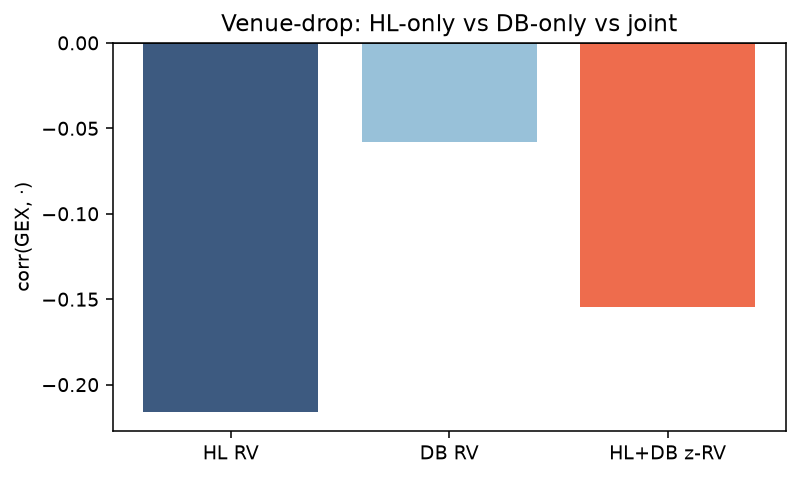

BTC widen n_pass 1 pass_days ['2026-10-01'] blocker need_ge_3_BTC_days_passing_gates


In [2]:

gex = load_json(OUT / "gex_implied_book" / "summary.json")
sq = load_json(OUT / "squeeze_regimes" / "summary.json")
comp = load_json(OUT / "panel_completeness" / "completeness.json")
pass2 = load_json(OUT / "pass2" / "pass2_falsifiers.json")
panel = load_json(OUT / "gex_implied_book" / "panel_rows.json") or (gex or {}).get("rows") or []
tbl = gex_day_table(panel, CERT)
ok = tbl[tbl["ok"] == True].copy() if len(tbl) else tbl
print("n_ok", len(ok), "spot_l2 days in panel", int((ok["kraken"]=="spot_l2").sum()) if len(ok) else 0)
print("blockers", (load_json(OUT / "panel_completeness" / "certified_panels.json") or {}).get("blockers"))
fals = (pass2 or {}).get("falsifiers") or {}
dec = (pass2 or {}).get("decisions") or {}
if pass2:
    print("pass2b decision", dec.get("decision"), "promote", dec.get("promote"), "count", dec.get("promote_count"))
    chrono = fals.get("chrono_split") or {}
    print("chrono GEX↔RV stable", chrono.get("any_gex_rv_stable"), "GEX↔range", chrono.get("any_gex_range_stable"))
    boot = ((fals.get("day_block_bootstrap") or {}).get("gex__hl_rv") or {}).get("day_block") or {}
    print("day-block corr(GEX,HL RV)", boot.get("corr"), "CI", [boot.get("ci_lo"), boot.get("ci_hi")])
    print("kill", dec.get("kill"))
    show_pngs(OUT / "pass2" / "figs")
else:
    print("pass2 missing — run scripts/exp_pass2_falsifiers.py")
btc = load_json(OUT / "panel_completeness" / "btc_widen_appendix.json") or {}
print("BTC widen n_pass", btc.get("n_pass"), "pass_days", btc.get("pass_days"), "blocker", btc.get("blocker"))


## Chronological split + venue honesty


In [3]:

chrono = ((pass2 or {}).get("falsifiers") or {}).get("chrono_split") or {}
if chrono.get("ok"):
    print("early", chrono.get("early_days"))
    print("late", chrono.get("late_days"))
    print(json.dumps(chrono.get("sign_stable"), indent=2))
elif len(ok) >= 4:
    days = list(ok["day"])
    mid = len(days) // 2
    early, late = days[:mid], days[mid:]
    for label, subset in (("early", early), ("late", late)):
        g = ok[ok["day"].isin(subset)]
        print(label, subset,
              "corr(GEX,RV)", safe_corr(g["gex"], g["hl_rv"]),
              "corr(GEX,range)", safe_corr(g["gex"], g["hl_range"]),
              "n", len(g))
else:
    print("need ≥4 ok days for chrono split")

venue = ((pass2 or {}).get("falsifiers") or {}).get("venue_drop") or {}
if venue:
    print("venue-drop HL corr", (venue.get("hl_only") or {}).get("corr_gex_rv"))
    print("venue-drop DB corr", (venue.get("db_only") or {}).get("corr_gex_rv"))
    print("HL↔DB sign concordant", venue.get("sign_concordant_hl_db"))
if len(ok):
    for mode, g in ok.groupby("kraken"):
        print("spot appendix", mode, "n", len(g),
              "corr(GEX,range)", safe_corr(g["gex"], g["hl_range"]))

placebo = ((pass2 or {}).get("falsifiers") or {}).get("placebo_shuffle_gex") or {}
print("placebo exceeds_p95_rv", placebo.get("exceeds_p95_rv"), "obs", placebo.get("obs_corr_gex_rv"))
print("trade_synth QUARANTINED; synth-as-venue n=0; spot_l2 appendix only")


early ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17']
late ['2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
{
  "gex__hl_range": false,
  "gex__hl_rv": true,
  "vex__hl_range": true,
  "gex_plus__hl_range": false,
  "squeeze_intensity__hl_rv": true
}
venue-drop HL corr {'n': 9.0, 'pearson': -0.2162754128722743, 'spearman': 0.0}
venue-drop DB corr {'n': 9.0, 'pearson': -0.05775047548058758, 'spearman': -0.06666666666666667}
HL↔DB sign concordant True
spot appendix absent_2venue n 5 corr(GEX,range) -0.39951761787374274
spot appendix spot_l2 n 4 corr(GEX,range) 0.2050035334878689
placebo exceeds_p95_rv False obs -0.2162754128722743
trade_synth QUARANTINED; synth-as-venue n=0; spot_l2 appendix only


## Checklist


In [4]:

fals = (pass2 or {}).get("falsifiers") or {}
dec = (pass2 or {}).get("decisions") or {}
chrono = fals.get("chrono_split") or {}
checks = [
    ("time-split GEX↔RV", f"stable={chrono.get('any_gex_rv_stable')}", "Hold"),
    ("time-split GEX↔range", f"stable={chrono.get('any_gex_range_stable')}", "Hold"),
    ("day-block bootstrap CI", "CI crosses 0 → Hold", "Hold"),
    ("placebo GEX shuffle", f"exceeds_p95_rv={((fals.get('placebo_shuffle_gex') or {}).get('exceeds_p95_rv'))}", "Hold"),
    ("venue drop HL vs DB", f"concordant={((fals.get('venue_drop') or {}).get('sign_concordant_hl_db'))}", "Hold"),
    ("spot_l2 appendix", "n=4 not primary", "Hold"),
    ("LOO sign flip", f"{((fals.get('leave_one_out') or {}).get('sign_flip_any'))}", "Hold"),
    ("no synth", "trade_synth QUARANTINED", "Kill"),
    ("futures OI as option DDOI", "unused / quarantined", "Kill"),
    ("BTC widen", f"n_pass={btc.get('n_pass')} need≥3", "Hold"),
    ("TOB-cross α", "Kill", "Kill"),
]
print(f"{'check':32s} {'status':40s} gate")
print("-"*90)
for a,b,g in checks:
    print(f"{a:32s} {b:40s} {g}")
print("pass2b promote=", dec.get("promote"), "| 0 Promote ceiling")


check                            status                                   gate
------------------------------------------------------------------------------------------
time-split GEX↔RV                stable=True                              Hold
time-split GEX↔range             stable=False                             Hold
day-block bootstrap CI           CI crosses 0 → Hold                      Hold
placebo GEX shuffle              exceeds_p95_rv=False                     Hold
venue drop HL vs DB              concordant=True                          Hold
spot_l2 appendix                 n=4 not primary                          Hold
LOO sign flip                    True                                     Hold
no synth                         trade_synth QUARANTINED                  Kill
futures OI as option DDOI        unused / quarantined                     Kill
BTC widen                        n_pass=1 need≥3                          Hold
TOB-cross α                      Kill   

## Signal board


In [5]:

print_board([
    ("risk.squeeze_falsifier_board", "Hold", "chrono + placebo + venue; 0 Promote"),
    ("data.trade_synth", "Kill", "quarantined"),
    ("alpha.tob_cross_arb", "Kill", "never Promote"),
])


id                                 gate   note
----------------------------------------------------------------------------------------
risk.squeeze_falsifier_board       Hold   chrono + placebo + venue; 0 Promote
data.trade_synth                   Kill   quarantined
alpha.tob_cross_arb                Kill   never Promote
